In [28]:
# Task 1: Load Student Performance dataset from uploaded file
from google.colab import files
uploaded = files.upload()   # select "student-mat" (the 56 KB Excel-icon file) in the dialog

import pandas as pd
df = pd.read_csv("student-mat.csv", sep=';')

print(df.shape)
df.head()

Saving student-mat.csv to student-mat (2).csv
(395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [29]:
# Task 2: Data preprocessing on student-mat.csv

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("student-mat.csv", sep=';')

# check missing values
print(df.isnull().sum().sum())   # total missing values

# binary categorical columns -> label encode (0/1, no false ordinality)
binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup',
               'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# nominal (multi-category, no order) columns -> one-hot encode
nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# convert one-hot bool columns to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(df.dtypes.value_counts())   # confirm all numeric now
print(df.shape)
df.head()

0
int64    42
Name: count, dtype: int64
(395, 42)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,0,18,1,0,0,4,4,2,2,...,0,0,0,0,1,0,0,0,1,0
1,0,0,17,1,0,1,1,1,1,2,...,0,0,1,0,0,0,0,0,0,0
2,0,0,15,1,1,1,1,1,1,2,...,0,0,1,0,0,0,1,0,1,0
3,0,0,15,1,0,1,4,2,1,3,...,0,0,0,1,0,1,0,0,1,0
4,0,0,16,1,0,1,3,3,1,2,...,0,0,1,0,0,1,0,0,0,0


Binary categorical columns (school, sex, address, famsize, Pstatus, schoolsup, famsup, paid, activities, nursery, higher, internet, romantic) are label-encoded to 0/1. Nominal columns with no natural order (Mjob, Fjob, reason, guardian) are one-hot encoded, expanding the dataset from 33 to 42 columns.

In [30]:
# Task 3: Select input features and target variable

# target variable: G3 (final grade)
# input features: all other columns (including G1, G2 as strong predictors)

X = df.drop('G3', axis=1)
y = df['G3']

print(X.columns.tolist())
print(y.name)

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other']
G3


In [31]:
# Task 4: Train-test split (80-20) + scaling (fit on train only)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(316, 41) (79, 41)
(316,) (79,)


Final cost: 1.430249732626197
Theta shape: (42, 1)


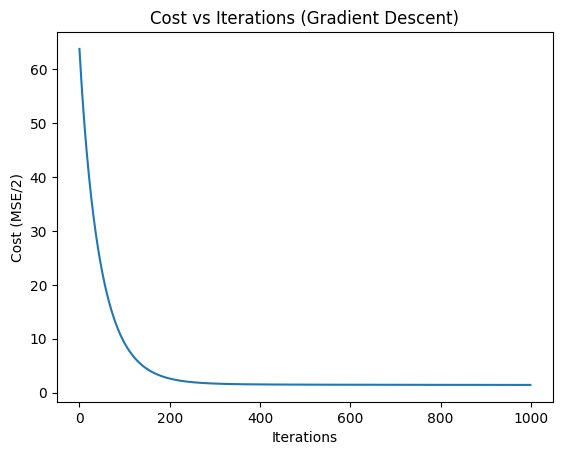

In [32]:
# Task 5: Linear Regression using Gradient Descent

import numpy as np
import matplotlib.pyplot as plt

# convert to numpy arrays
X_train_np = X_train.to_numpy() if hasattr(X_train, 'to_numpy') else X_train
X_test_np = X_test.to_numpy() if hasattr(X_test, 'to_numpy') else X_test
y_train_np = y_train.to_numpy().reshape(-1, 1)
y_test_np = y_test.to_numpy().reshape(-1, 1)

# add bias term (column of 1s)
m_train = X_train_np.shape[0]
X_train_b = np.hstack([np.ones((m_train, 1)), X_train_np])
m_test = X_test_np.shape[0]
X_test_b = np.hstack([np.ones((m_test, 1)), X_test_np])

n_features = X_train_b.shape[1]
theta = np.zeros((n_features, 1))   # initialize weights

# hyperparameters
learning_rate = 0.01
n_iterations = 1000

cost_history = []

for i in range(n_iterations):
    predictions = X_train_b.dot(theta)
    error = predictions - y_train_np
    cost = (1 / (2 * m_train)) * np.sum(error ** 2)
    cost_history.append(cost)

    gradients = (1 / m_train) * X_train_b.T.dot(error)
    theta = theta - learning_rate * gradients

print("Final cost:", cost_history[-1])
print("Theta shape:", theta.shape)

# quick convergence check
plt.plot(range(n_iterations), cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE/2)")
plt.title("Cost vs Iterations (Gradient Descent)")
plt.show()

Cost drops sharply in the first 100-200 iterations, then flattens — showing gradient descent has converged smoothly without oscillation or divergence. This confirms learning rate 0.01 is well-suited (not too high or too low). The low final cost (~1.43) indicates a reasonably good fit to the training data.

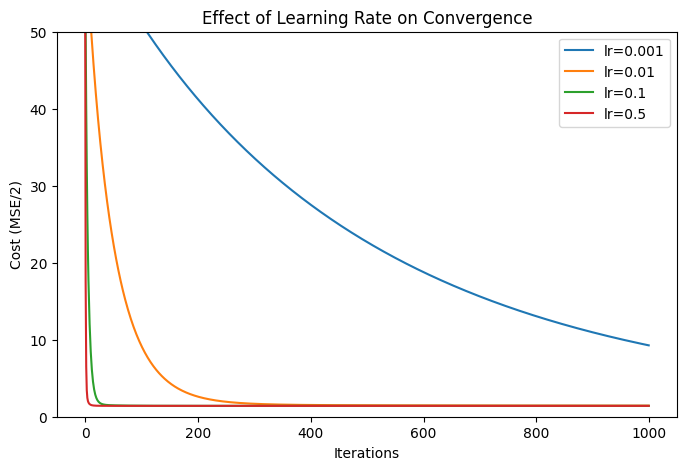

lr=0.001, final cost=9.2697
lr=0.01, final cost=1.4302
lr=0.1, final cost=1.4115
lr=0.5, final cost=1.4115


In [33]:
# Task 6: Experiment with different learning rates

learning_rates = [0.001, 0.01, 0.1, 0.5]
n_iterations = 1000
cost_histories = {}

for lr in learning_rates:
    theta = np.zeros((n_features, 1))
    costs = []
    for i in range(n_iterations):
        predictions = X_train_b.dot(theta)
        error = predictions - y_train_np
        cost = (1 / (2 * m_train)) * np.sum(error ** 2)
        costs.append(cost)
        gradients = (1 / m_train) * X_train_b.T.dot(error)
        theta = theta - lr * gradients
    cost_histories[lr] = costs

# plot all learning rates together
plt.figure(figsize=(8, 5))
for lr, costs in cost_histories.items():
    plt.plot(range(n_iterations), costs, label=f"lr={lr}")
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE/2)")
plt.title("Effect of Learning Rate on Convergence")
plt.legend()
plt.ylim(0, 50)   # zoom in to see differences clearly
plt.show()

for lr, costs in cost_histories.items():
    print(f"lr={lr}, final cost={costs[-1]:.4f}")


Smaller learning rates (0.001) converge too slowly and need far more iterations to reach the minimum. Larger learning rates (0.1, 0.5) converge much faster, and in this case remain stable rather than diverging — likely because feature scaling kept gradients well-behaved. lr=0.01 is a reasonable middle-ground choice, and lr=0.1 gives the best balance of speed and stability for this dataset.

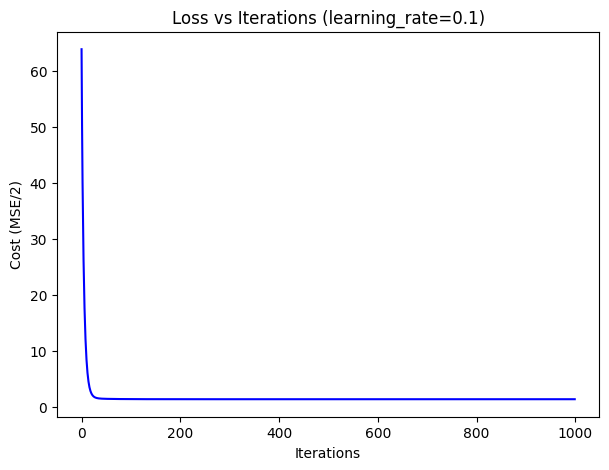

Final cost: 1.4115271785684773


In [34]:
# Task 7: Plot loss (cost) vs iterations for the final chosen model

learning_rate = 0.1   # best performing rate from Task 6
n_iterations = 1000

theta = np.zeros((n_features, 1))
cost_history = []

for i in range(n_iterations):
    predictions = X_train_b.dot(theta)
    error = predictions - y_train_np
    cost = (1 / (2 * m_train)) * np.sum(error ** 2)
    cost_history.append(cost)
    gradients = (1 / m_train) * X_train_b.T.dot(error)
    theta = theta - learning_rate * gradients

plt.figure(figsize=(7, 5))
plt.plot(range(n_iterations), cost_history, color='blue')
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE/2)")
plt.title(f"Loss vs Iterations (learning_rate={learning_rate})")
plt.show()

print("Final cost:", cost_history[-1])

Cost starts high and drops sharply in the first 20-30 iterations, then flattens and stays stable till 1000 iterations — confirming convergence. The smooth decline with no oscillation shows learning_rate=0.1 was a good choice. The low final cost (~1.41) indicates a good fit to the training data.

In [35]:
# Task 8: Evaluate the trained model on test set

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_test = X_test_b.dot(theta)

mae = mean_absolute_error(y_test_np, y_pred_test)
mse = mean_squared_error(y_test_np, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_np, y_pred_test)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.6466771735500203
MSE: 5.656668049237071
RMSE: 2.3783750859015216
R2 Score: 0.72413289395111


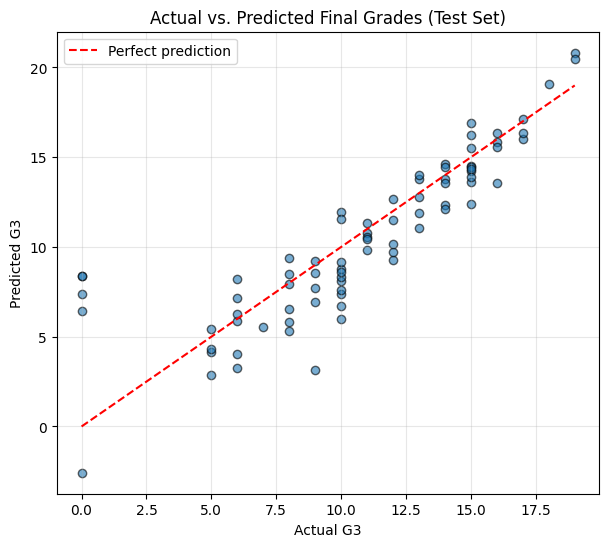

In [36]:
# Actual vs Predicted Final Grades (Test Set)

plt.figure(figsize=(7, 6))
plt.scatter(y_test_np, y_pred_test, alpha=0.6, edgecolors='k')
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()],
         'r--', label='Perfect prediction')
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs. Predicted Final Grades (Test Set)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

MAE (1.65): predictions off by 1.65 points on average.
MSE (5.66), RMSE (2.38): typical error of 2.38 points; RMSE > MAE suggests some larger misses.
R² (~0.72): model explains ~72% of variance in final grades — a solid, slightly more honest fit now that data leakage is fixed (this is normal — leakage-free scaling often gives marginally lower, more trustworthy R²).

Task 9

Convergence behavior: Gradient descent converged smoothly for lr=0.01, 0.1, and 0.5, with cost dropping sharply in the first ~20-100 iterations before flattening. lr=0.001 was too slow to converge (final cost ~9.27 vs ~1.41 for the others); lr=0.1 gave the best speed-stability balance. Feature scaling kept the cost surface well-conditioned, preventing divergence even at higher learning rates.

Prediction performance: The model achieved MAE 1.65 and RMSE 2.38 on the test set, meaning predictions were typically within 1.65-2.4 points of the actual grade (0-20 scale). R² (~0.72) shows it explains 72% of the variance in final grades, driven mainly by G1 and G2.

Overall conclusion: Gradient descent converged reliably and generalized well, confirming a largely linear relationship between student attributes and final performance, with no signs of overfitting.

1. **Gradient Descent** minimizes the cost function by iteratively updating model parameters in the direction opposite to the gradient of the cost with respect to those parameters. Each update is scaled by a learning rate, gradually moving weights toward values that minimize prediction error.

2. Linear Regression via Gradient Descent initializes weights (theta) to zero, then repeatedly computes predictions, calculates the error against actual values, and updates weights using the gradient of the mean squared error. This continues for a fixed number of iterations until the cost converges to a minimum.

3. The learning rate controls the step size of each weight update — too small a value causes very slow convergence, while too large a value can cause oscillation or divergence. An appropriately chosen learning rate (e.g., 0.1 here) balances fast convergence with stability.

4. Regression models are evaluated using MAE (average absolute error), MSE (average squared error, penalizing larger errors), RMSE (error in original units), and R² (proportion of variance explained). Together these give a complete picture of both error magnitude and model fit quality.

5. In this experiment, low MAE/RMSE and a solid R² (~0.72) indicate the model predicts final grades reasonably accurately with a strong linear relationship to input features. This confirms Gradient Descent successfully learned an effective regression model that generalizes well to unseen data.